In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

In [57]:
train_data = pd.read_csv("digit.csv")
print("Shape of tarin_data:", train_data.shape)

X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after seperating feaures:", X.shape)

Shape of tarin_data: (42000, 785)
Shape of X after seperating feaures: (42000, 784)


In [58]:
# Check if X is not a pandas DataFrame
# If it is not, convert it into DataFrame 
# This ensures that DataFrme modules like .apply can be used sefty 
if not isinstance(X, pd.DataFrame):
    x = pd.DataFrame(x)

# Convert all values in X to nemeric type
# If any values cannot be converted, replace it with NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Repalce all NaN (missing/invalid) values with 0 
# This prevents error during the model training 
X = X.fillna(0)

# Convert DataFrame to NumPy array
# Normalize pixel values from range(0-255) to (0-1)
# Neural networks train better with normalized inputs
X = X.values / 255.0

# Reshape the flattened image data into 28x28 format
# -1 automatically determines number of samples
# 28 = image height
# 28 = image width
# 1 = number of channels (grayscale image)
X = X.reshape(-1, 28, 28, 1)

print("Shape of X after reshaping: ", X.shape)

Shape of X after reshaping:  (42000, 28, 28, 1)


In [59]:
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding: ", y.shape)

Shape of y after one-hot encoding:  (42000, 10)


In [60]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_tarin shape:", X_train.shape)

X_tarin shape: (33600, 28, 28, 1)


In [61]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9087 - loss: 0.3098 - val_accuracy: 0.9452 - val_loss: 0.1771
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9624 - loss: 0.1278 - val_accuracy: 0.9601 - val_loss: 0.1337
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9737 - loss: 0.0869 - val_accuracy: 0.9655 - val_loss: 0.1078
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9799 - loss: 0.0657 - val_accuracy: 0.9680 - val_loss: 0.1060
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9843 - loss: 0.0488 - val_accuracy: 0.9698 - val_loss: 0.1022
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9878 - loss: 0.0379 - val_accuracy: 0.9598 - val_loss: 0.1380
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9898 - loss: 0.0317 - val_accuracy: 0.9748 - val_loss: 0.0903
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9915 - loss: 0.0260 - 

In [63]:
# ================================
# Extract Final Accuracies
# ================================

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
best_val_acc = max(history.history['val_accuracy'])

print("\n===== Final Results =====")
print(f"Final Training Accuracy     : {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy   : {val_acc * 100:.2f}%")
print(f"Best Validation Accuracy    : {best_val_acc * 100:.2f}%")

# ================================
# Print Accuracy Per Epoch
# ================================

print("\n===== Accuracy Per Epoch =====")
for epoch in range(len(history.history['accuracy'])):
    print(f"Epoch {epoch+1}: "
          f"Train Acc = {history.history['accuracy'][epoch]*100:.2f}% | "
          f"Val Acc = {history.history['val_accuracy'][epoch]*100:.2f}%")


===== Final Results =====
Final Training Accuracy     : 99.32%
Final Validation Accuracy   : 97.39%
Best Validation Accuracy    : 97.48%

===== Accuracy Per Epoch =====
Epoch 1: Train Acc = 90.87% | Val Acc = 94.52%
Epoch 2: Train Acc = 96.24% | Val Acc = 96.01%
Epoch 3: Train Acc = 97.37% | Val Acc = 96.55%
Epoch 4: Train Acc = 97.99% | Val Acc = 96.80%
Epoch 5: Train Acc = 98.43% | Val Acc = 96.98%
Epoch 6: Train Acc = 98.78% | Val Acc = 95.98%
Epoch 7: Train Acc = 98.98% | Val Acc = 97.48%
Epoch 8: Train Acc = 99.15% | Val Acc = 97.17%
Epoch 9: Train Acc = 99.21% | Val Acc = 97.29%
Epoch 10: Train Acc = 99.32% | Val Acc = 97.39%


263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9739 - loss: 0.1093
Valudation Accuracy: 97.39%


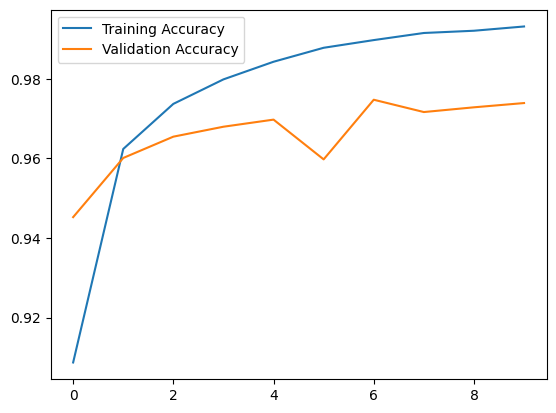

In [64]:
val_loss, val_acccuracy = model.evaluate(X_val, y_val)
print(f"Valudation Accuracy: {val_acccuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


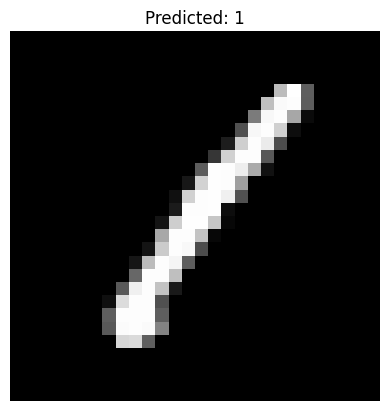

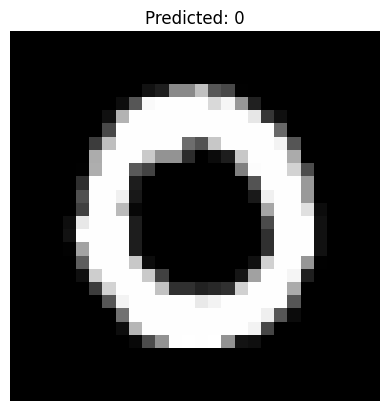

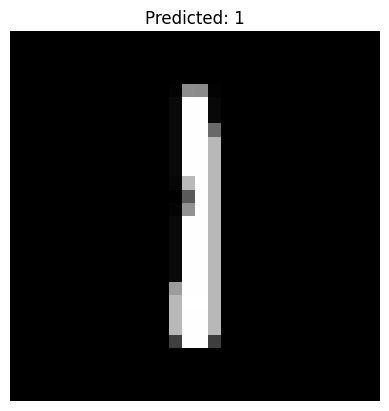

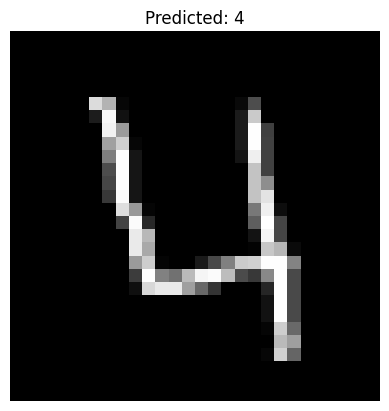

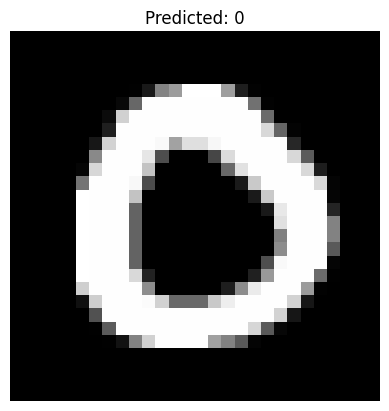

In [65]:
# Load the dataset
test_data = pd.read_csv('digit.csv')

# Remove label column (first column)
X_test = test_data.iloc[:, 1:].values / 255.0  

# Reshape to (samples, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Make predictions
predictions = model.predict(X_test)

# Get predicted digit (highest probability index)
predicted_labels = np.argmax(predictions, axis=1)

# Show first 5 predictions
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()

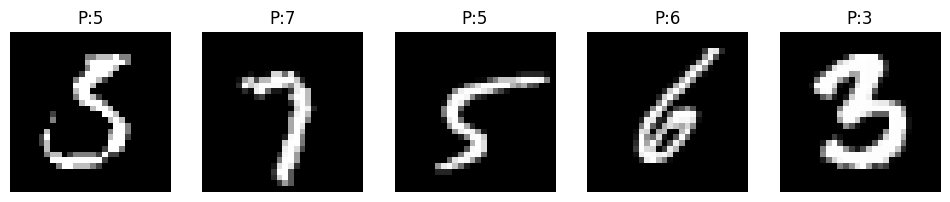

In [73]:
random_indices = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,3))

for idx, i in enumerate(random_indices):
    plt.subplot(1, 5, idx+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]}")
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


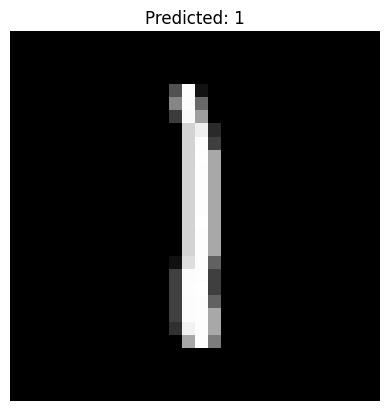

In [80]:
def show_image(index):
    # Get image
    image = X_test[index]
    
    # Predict digit
    prediction = model.predict(image.reshape(1, 28, 28, 1))
    predicted_label = np.argmax(prediction)
    
    # Show image
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

show_image(1000)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


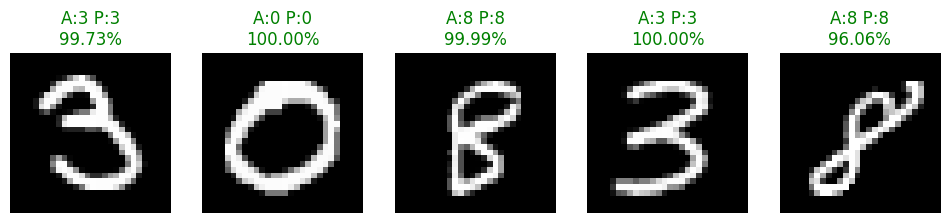

Total Wrong Predictions: 305


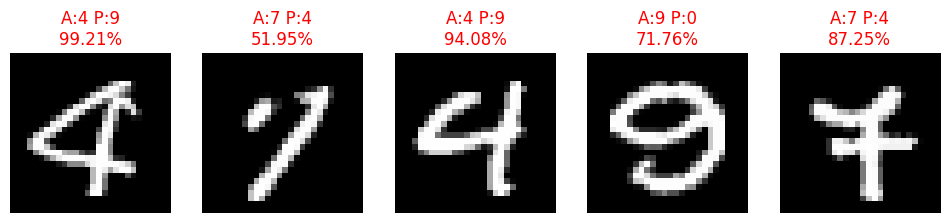

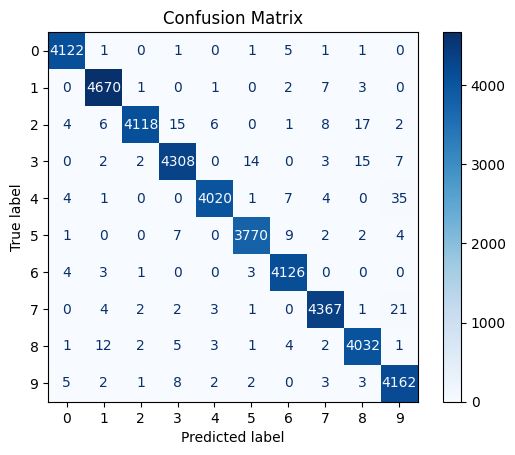

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get actual labels
y_test = test_data.iloc[:, 0].values

# Get model predictions
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# =========================
# 1️⃣ Show Random Predictions
# =========================

random_indices = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12,3))

for idx, i in enumerate(random_indices):
    plt.subplot(1, 5, idx+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    
    confidence = np.max(predictions[i]) * 100
    
    if predicted_labels[i] == y_test[i]:
        color = "green"
    else:
        color = "red"
        
    plt.title(f"A:{y_test[i]} P:{predicted_labels[i]}\n{confidence:.2f}%", color=color)
    plt.axis('off')

plt.show()


# =========================
# 2️⃣ Show Only Wrong Predictions
# =========================

wrong_indices = np.where(predicted_labels != y_test)[0]

print(f"Total Wrong Predictions: {len(wrong_indices)}")

if len(wrong_indices) > 0:
    plt.figure(figsize=(12,3))
    
    for idx, i in enumerate(wrong_indices[:5]):  # show first 5 wrong
        plt.subplot(1, 5, idx+1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
        
        confidence = np.max(predictions[i]) * 100
        
        plt.title(f"A:{y_test[i]} P:{predicted_labels[i]}\n{confidence:.2f}%", color="red")
        plt.axis('off')
    
    plt.show()


# =========================
# 3️⃣ Confusion Matrix
# =========================

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()